In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
df = pd.read_csv('Housing.csv')

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
print("columns:", df.columns)
print("shape:", df.shape)

columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
shape: (545, 13)


In [ ]:
print("missing values :", df.isnull().sum())

missing values : price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
print("duplicate data:", df.duplicated().sum())

duplicate data: 0


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:

yes_no = ['mainroad', 'guestroom', 'basement',
          'hotwaterheating', 'airconditioning', 'prefarea']

for col in yes_no:
    df[col] = df[col].map({'yes': 1, 'no': 0})


df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df = df.astype({col: int for col in df.select_dtypes('bool').columns})

print(df.head())

      price  ...  furnishingstatus_unfurnished
0  13300000  ...                             0
1  12250000  ...                             0
2  12250000  ...                             0
3  12215000  ...                             0
4  11410000  ...                             0

[5 rows x 14 columns]


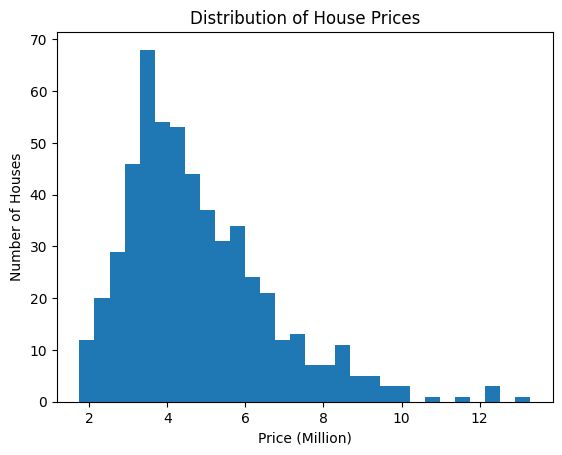

In [ ]:

plt.hist(df['price'] / 1e6, bins=30)
plt.xlabel("Price (Million)")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

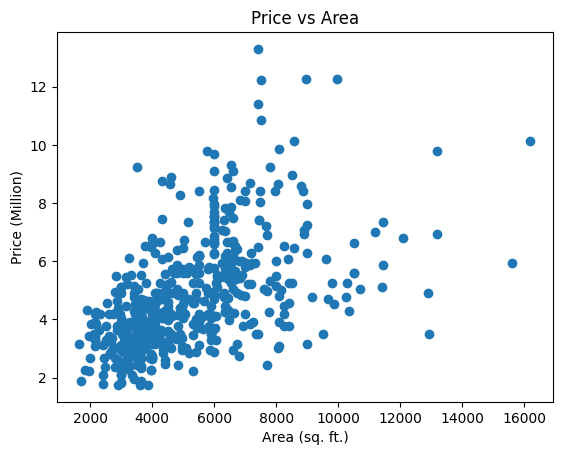

In [ ]:
plt.scatter(df['area'], df['price'] / 1e6)
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price (Million)")
plt.title("Price vs Area")
plt.show()

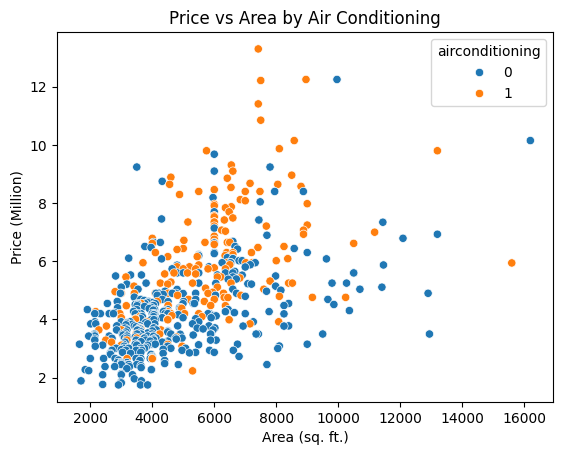

In [ ]:
sns.scatterplot(data=df, x='area', y=df['price']/1e6,
                hue='airconditioning')

plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price (Million)")
plt.title("Price vs Area by Air Conditioning")
plt.show()

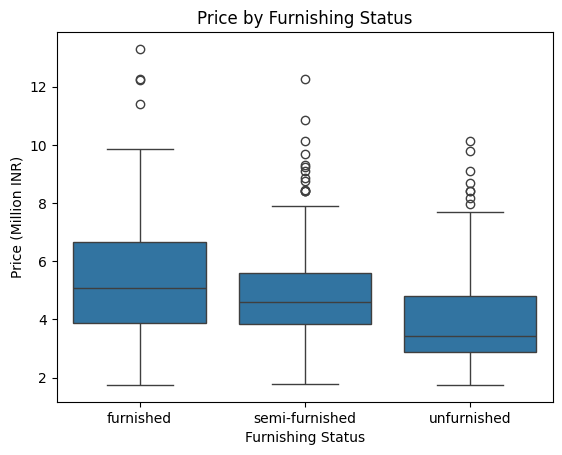

In [ ]:
def get_original_furnishing_status(row):
    if row['furnishingstatus_semi-furnished'] == 1:
        return 'semi-furnished'
    elif row['furnishingstatus_unfurnished'] == 1:
        return 'unfurnished'
    else:
        return 'furnished'

df['original_furnishingstatus'] = df.apply(get_original_furnishing_status, axis=1)

sns.boxplot(data=df, x='original_furnishingstatus', y=df['price']/1e6)

plt.xlabel("Furnishing Status")
plt.ylabel("Price (Million INR)")
plt.title("Price by Furnishing Status")
plt.show()

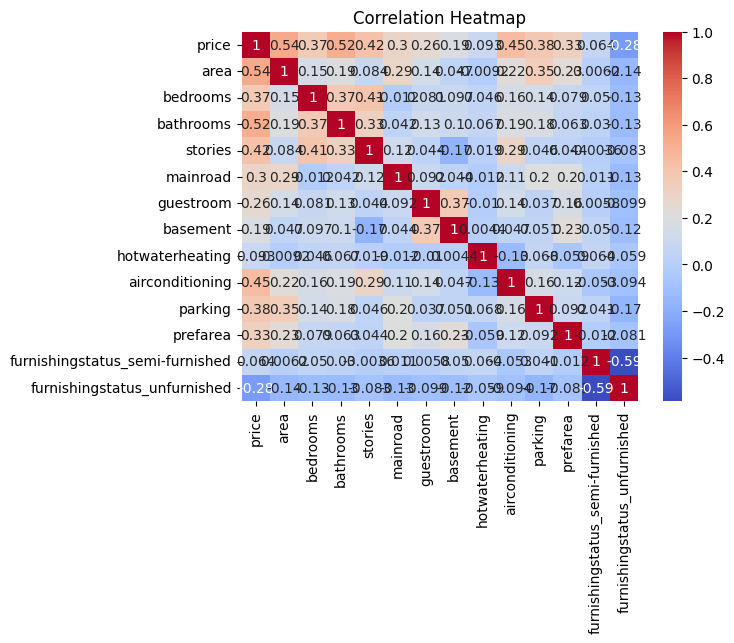

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop(["price", "original_furnishingstatus"], axis=1)
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

In [ ]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.6529242642153185
MAE: 970043.4039201637
RMSE: 1324506.9600914384


In [ ]:
X_train_ols = sm.add_constant(X_train)

ols = sm.OLS(y_train, X_train_ols).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     70.90
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           2.16e-97
Time:                        18:24:50   Log-Likelihood:                -6635.2
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     422   BIC:                         1.336e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:
vif = pd.DataFrame()
vif["Variable"] = X_train.columns
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif.sort_values("VIF", ascending=False))

                           Variable        VIF
1                          bedrooms  17.255074
2                         bathrooms  10.118570
0                              area   8.030463
3                           stories   7.990720
4                          mainroad   6.957378
11  furnishingstatus_semi-furnished   2.437430
6                          basement   2.116071
12     furnishingstatus_unfurnished   2.009241
9                           parking   1.988904
8                   airconditioning   1.814088
5                         guestroom   1.535238
10                         prefarea   1.487112
7                   hotwaterheating   1.093303


In [ ]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values("Coefficient", ascending=False))

                           Variable   Coefficient
2                         bathrooms  1.094445e+06
8                   airconditioning  7.914267e+05
7                   hotwaterheating  6.846499e+05
10                         prefarea  6.298906e+05
3                           stories  4.074766e+05
6                          basement  3.902512e+05
4                          mainroad  3.679199e+05
5                         guestroom  2.316100e+05
9                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05


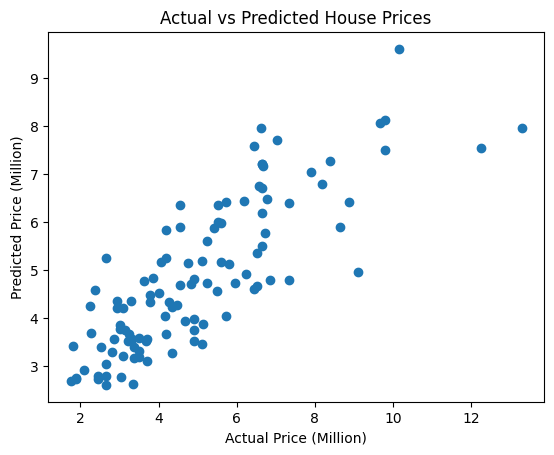

In [ ]:
plt.scatter(y_test / 1e6, y_pred / 1e6)

plt.xlabel("Actual Price (Million)")
plt.ylabel("Predicted Price (Million)")
plt.title("Actual vs Predicted House Prices")

plt.show()

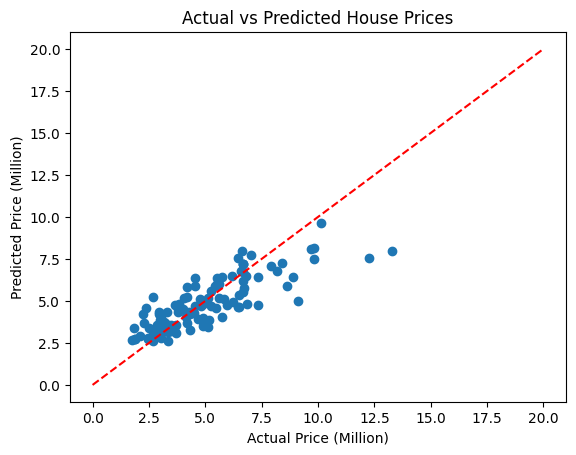

In [ ]:
plt.scatter(y_test / 1e6, y_pred / 1e6)

plt.plot([0, 20], [0, 20], 'r--')

plt.xlabel("Actual Price (Million)")
plt.ylabel("Predicted Price (Million)")
plt.title("Actual vs Predicted House Prices")

plt.show()

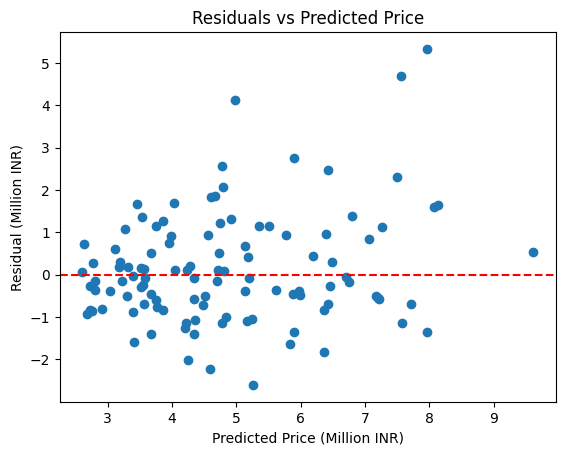

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred / 1e6, residuals / 1e6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price (Million INR)")
plt.ylabel("Residual (Million INR)")
plt.title("Residuals vs Predicted Price")

plt.show()

=== VIF BEFORE FIX ===
                            feature        VIF
0                          bedrooms  17.255074
1                         bathrooms  10.118570
2                              area   8.030463
3                           stories   7.990720
4                          mainroad   6.957378
5   furnishingstatus_semi-furnished   2.437430
6                          basement   2.116071
7      furnishingstatus_unfurnished   2.009241
8                           parking   1.988904
9                   airconditioning   1.814088
10                        guestroom   1.535238
11                         prefarea   1.487112
12                  hotwaterheating   1.093303

=== VIF AFTER FIX ===
                            feature       VIF
0                         bathrooms  8.491519
1                              area  7.590323
2                          mainroad  6.856384
3                           stories  6.343188
4   furnishingstatus_semi-furnished  2.283077
5                   

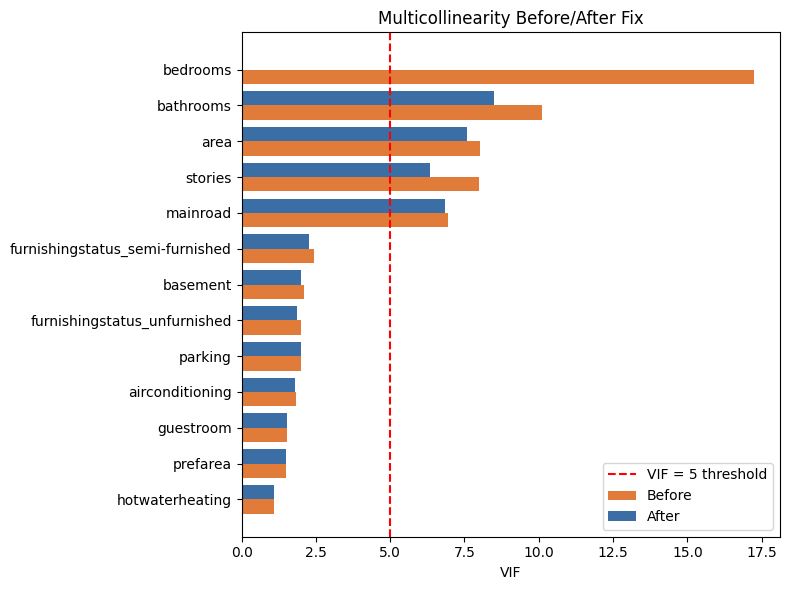

In [ ]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    vif = pd.DataFrame()
    vif['feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

print("=== VIF BEFORE FIX ===")
print(compute_vif(X_train))


X_train_fixed = X_train.drop(columns=['bedrooms'])
X_test_fixed = X_test.drop(columns=['bedrooms'])

print("\n=== VIF AFTER FIX ===")
print(compute_vif(X_train_fixed))


X_train_sm_fixed = sm.add_constant(X_train_fixed)
model_final = sm.OLS(y_train, X_train_sm_fixed).fit()
print(model_final.summary())


lr_final = LinearRegression()
lr_final.fit(X_train_fixed, y_train)
y_pred_final = lr_final.predict(X_test_fixed)
print("Corrected Test R2:", r2_score(y_test, y_pred_final))
print("Corrected Test MAE:", mean_absolute_error(y_test, y_pred_final))


from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fixed)
X_test_scaled = scaler.transform(X_test_fixed)

ridge = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5)
ridge.fit(X_train_scaled, y_train)
print("Best alpha:", ridge.alpha_)
y_pred_ridge = ridge.predict(X_test_scaled)
print("Ridge Test R2:", r2_score(y_test, y_pred_ridge))

vif_before = compute_vif(X_train)
vif_after = compute_vif(X_train_fixed)
merged = vif_before.rename(columns={'VIF':'VIF_before'}).merge(
    vif_after.rename(columns={'VIF':'VIF_after'}), on='feature', how='left')
merged = merged.sort_values('VIF_before', ascending=True)

plt.figure(figsize=(8,6))
y_pos = np.arange(len(merged))
plt.barh(y_pos-0.2, merged['VIF_before'], height=0.4, label='Before', color='#e07b39')
plt.barh(y_pos+0.2, merged['VIF_after'].fillna(0), height=0.4, label='After', color='#3b6ea5')
plt.axvline(5, color='red', linestyle='--', label='VIF = 5 threshold')
plt.yticks(y_pos, merged['feature'])
plt.xlabel('VIF'); plt.title('Multicollinearity Before/After Fix')
plt.legend(); plt.tight_layout(); plt.show()